# ============================================================
# Author: Mayur Deshmukh
# Title: 04_model_predict.ipynb
# Project: ML-Binary-Classifier-For-Stock-Price-rediction
# Purpose: Training ML Models for Binary Classification
# Python Version: 3.11
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

output_dir = os.path.join('..', '..', 'output')

In [2]:
# Load feature-engineered and pre-split datasets from the output folder
X_train = pd.read_csv(os.path.join(output_dir, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(output_dir, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(output_dir, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(output_dir, 'y_test.csv')).squeeze()

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test  distribution:\n{y_test.value_counts()}")

X_train : (9330, 17)  |  X_test : (2770, 17)
y_train : (9330,)  |  y_test : (2770,)

y_train distribution:
target
1    4818
0    4512
Name: count, dtype: int64

y_test  distribution:
target
1    1500
0    1270
Name: count, dtype: int64


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import GridSearchCV

print("=" * 60)
print("=== STEP 1: LOGISTIC REGRESSION - BASELINE ===")
print("=" * 60)

# Train a baseline Logistic Regression with default parameters
try:
    lr_baseline = LogisticRegression(random_state=42, max_iter=200, n_jobs=-1)
    lr_baseline.fit(X_train, y_train)

    y_pred_baseline = lr_baseline.predict(X_test)
    y_prob_baseline = lr_baseline.predict_proba(X_test)[:, 1]

    print(f"Baseline Accuracy  : {accuracy_score(y_test, y_pred_baseline):.4f}")
    print(f"Baseline Precision : {precision_score(y_test, y_pred_baseline):.4f}")
    print(f"Baseline Recall    : {recall_score(y_test, y_pred_baseline):.4f}")
    print(f"Baseline F1        : {f1_score(y_test, y_pred_baseline):.4f}")
    print(f"Baseline ROC-AUC   : {roc_auc_score(y_test, y_prob_baseline):.4f}")

except Exception as e:
    print(f"[ERROR] Baseline Logistic Regression failed: {e}")

=== STEP 1: LOGISTIC REGRESSION - BASELINE ===
Baseline Accuracy  : 0.6690
Baseline Precision : 0.6628
Baseline Recall    : 0.7913
Baseline F1        : 0.7214
Baseline ROC-AUC   : 0.7424


In [4]:
print("=" * 60)
print("=== STEP 1: LOGISTIC REGRESSION - HYPERPARAMETER TUNING ===")
print("=" * 60)

# GridSearchCV with multiple scoring metrics; refit on roc_auc
param_grid = {
    'C'        : [0.01, 0.1, 1, 10, 100],
    'penalty'  : ['l1', 'l2'],
    'solver'   : ['liblinear', 'saga'],
    'max_iter' : [200, 500]
}

scoring = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1',
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall'
}

try:
    lr_grid = GridSearchCV(
        estimator  = LogisticRegression(random_state=42, n_jobs=-1),
        param_grid = param_grid,
        scoring    = scoring,
        refit      = 'roc_auc',
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    lr_grid.fit(X_train, y_train)

    print(f"\nBest hyperparameters found:")
    for param, val in lr_grid.best_params_.items():
        print(f"  {param}: {val}")
    print(f"\nBest CV ROC-AUC: {lr_grid.best_score_:.4f}")

except Exception as e:
    print(f"[ERROR] GridSearchCV for Logistic Regression failed: {e}")

=== STEP 1: LOGISTIC REGRESSION - HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best hyperparameters found:
  C: 100
  max_iter: 500
  penalty: l1
  solver: liblinear

Best CV ROC-AUC: 0.9363


In [5]:
print("=" * 60)
print("=== STEP 1: LOGISTIC REGRESSION - FINAL PREDICTIONS ===")
print("=" * 60)

# Use the best estimator from GridSearchCV for final predictions on test set
try:
    lr_best = lr_grid.best_estimator_

    y_pred_lr = lr_best.predict(X_test)
    y_prob_lr = lr_best.predict_proba(X_test)[:, 1]

    print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
    print(f"Tuned Precision : {precision_score(y_test, y_pred_lr):.4f}")
    print(f"Tuned Recall    : {recall_score(y_test, y_pred_lr):.4f}")
    print(f"Tuned F1        : {f1_score(y_test, y_pred_lr):.4f}")
    print(f"Tuned ROC-AUC   : {roc_auc_score(y_test, y_prob_lr):.4f}")

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred_lr, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    print(f"[ERROR] Final predictions for Logistic Regression failed: {e}")

=== STEP 1: LOGISTIC REGRESSION - FINAL PREDICTIONS ===
Tuned Accuracy  : 0.8610
Tuned Precision : 0.8535
Tuned Recall    : 0.8973
Tuned F1        : 0.8749
Tuned ROC-AUC   : 0.9354

Classification Report:

              precision    recall  f1-score   support

    Down (0)       0.87      0.82      0.84      1270
      Up (1)       0.85      0.90      0.87      1500

    accuracy                           0.86      2770
   macro avg       0.86      0.86      0.86      2770
weighted avg       0.86      0.86      0.86      2770



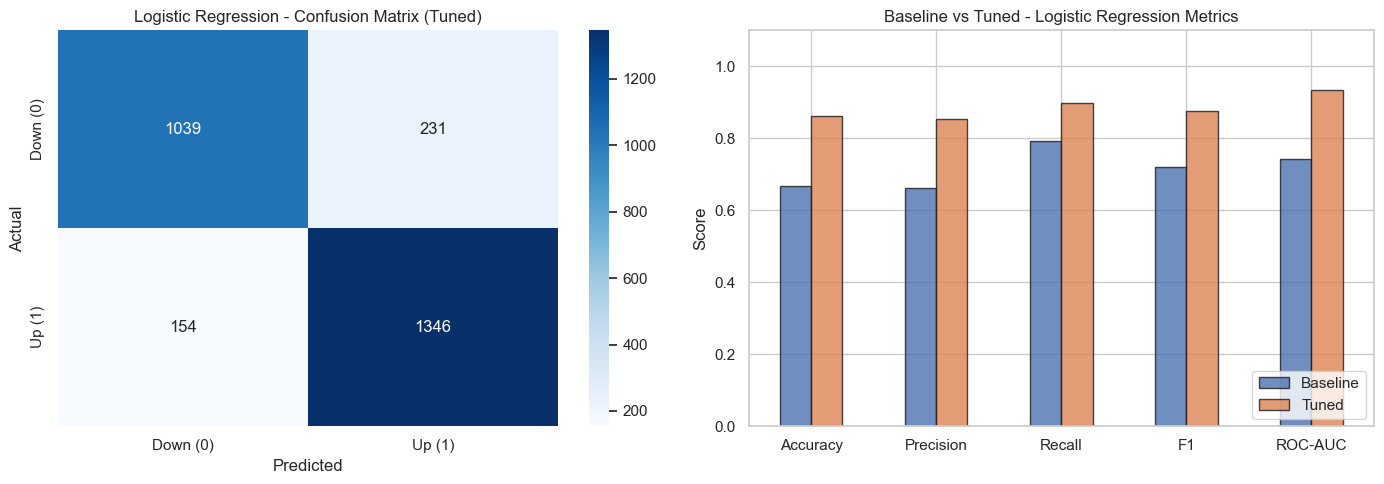


Baseline vs Tuned Metrics:


,Baseline,Tuned
Accuracy,0.6690,0.8610
Precision,0.6628,0.8535
Recall,0.7913,0.8973
F1,0.7214,0.8749
ROC-AUC,0.7424,0.9354


In [6]:
# Plot confusion matrix and compare baseline vs tuned metrics side by side
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix - tuned model
    cm = confusion_matrix(y_test, y_pred_lr)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    axes[0].set_title('Logistic Regression - Confusion Matrix (Tuned)')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Bar chart: baseline vs tuned metrics
    metrics_compare = pd.DataFrame({
        'Baseline': {
            'Accuracy' : accuracy_score(y_test, y_pred_baseline),
            'Precision': precision_score(y_test, y_pred_baseline),
            'Recall'   : recall_score(y_test, y_pred_baseline),
            'F1'       : f1_score(y_test, y_pred_baseline),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_baseline)
        },
        'Tuned': {
            'Accuracy' : accuracy_score(y_test, y_pred_lr),
            'Precision': precision_score(y_test, y_pred_lr),
            'Recall'   : recall_score(y_test, y_pred_lr),
            'F1'       : f1_score(y_test, y_pred_lr),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_lr)
        }
    })

    metrics_compare.plot(kind='bar', ax=axes[1], edgecolor='k', alpha=0.8)
    axes[1].set_title('Baseline vs Tuned - Logistic Regression Metrics')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'lr_evaluation.png'), bbox_inches='tight')
    plt.show()

    print("\nBaseline vs Tuned Metrics:")
    display(metrics_compare.round(4))

except Exception as e:
    print(f"[ERROR] Plotting failed: {e}")

In [7]:
from sklearn.svm import SVC

print("=" * 60)
print("=== STEP 2: SUPPORT VECTOR MACHINE - BASELINE ===")
print("=" * 60)

# Train a baseline SVC with default parameters; probability=True enables ROC-AUC scoring
try:
    svc_baseline = SVC(random_state=42, probability=True)
    svc_baseline.fit(X_train, y_train)

    y_pred_svc_baseline = svc_baseline.predict(X_test)
    y_prob_svc_baseline = svc_baseline.predict_proba(X_test)[:, 1]

    print(f"Baseline Accuracy  : {accuracy_score(y_test, y_pred_svc_baseline):.4f}")
    print(f"Baseline Precision : {precision_score(y_test, y_pred_svc_baseline):.4f}")
    print(f"Baseline Recall    : {recall_score(y_test, y_pred_svc_baseline):.4f}")
    print(f"Baseline F1        : {f1_score(y_test, y_pred_svc_baseline):.4f}")
    print(f"Baseline ROC-AUC   : {roc_auc_score(y_test, y_prob_svc_baseline):.4f}")

except Exception as e:
    print(f"[ERROR] Baseline SVM failed: {e}")

=== STEP 2: SUPPORT VECTOR MACHINE - BASELINE ===
Baseline Accuracy  : 0.7079
Baseline Precision : 0.6987
Baseline Recall    : 0.8100
Baseline F1        : 0.7502
Baseline ROC-AUC   : 0.7766


In [8]:
print("=" * 60)
print("=== STEP 2: SUPPORT VECTOR MACHINE - HYPERPARAMETER TUNING ===")
print("=" * 60)

# GridSearchCV over C, kernel, and gamma; probability=True required for roc_auc scoring
svc_param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma'  : ['scale', 'auto']
}

svc_scoring = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1',
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall'
}

try:
    svc_grid = GridSearchCV(
        estimator  = SVC(random_state=42, probability=True),
        param_grid = svc_param_grid,
        scoring    = svc_scoring,
        refit      = 'roc_auc',
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    svc_grid.fit(X_train, y_train)

    print(f"\nBest hyperparameters found:")
    for param, val in svc_grid.best_params_.items():
        print(f"  {param}: {val}")
    print(f"\nBest CV ROC-AUC: {svc_grid.best_score_:.4f}")

except Exception as e:
    print(f"[ERROR] GridSearchCV for SVM failed: {e}")

=== STEP 2: SUPPORT VECTOR MACHINE - HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best hyperparameters found:
  C: 100
  gamma: scale
  kernel: poly

Best CV ROC-AUC: 0.9258


In [9]:
print("=" * 60)
print("=== STEP 2: SUPPORT VECTOR MACHINE - FINAL PREDICTIONS ===")
print("=" * 60)

# Use the best estimator from GridSearchCV to generate final test set predictions
try:
    svc_best = svc_grid.best_estimator_

    y_pred_svc = svc_best.predict(X_test)
    y_prob_svc = svc_best.predict_proba(X_test)[:, 1]

    print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_svc):.4f}")
    print(f"Tuned Precision : {precision_score(y_test, y_pred_svc):.4f}")
    print(f"Tuned Recall    : {recall_score(y_test, y_pred_svc):.4f}")
    print(f"Tuned F1        : {f1_score(y_test, y_pred_svc):.4f}")
    print(f"Tuned ROC-AUC   : {roc_auc_score(y_test, y_prob_svc):.4f}")

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred_svc, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    print(f"[ERROR] Final predictions for SVM failed: {e}")

=== STEP 2: SUPPORT VECTOR MACHINE - FINAL PREDICTIONS ===
Tuned Accuracy  : 0.8549
Tuned Precision : 0.8607
Tuned Recall    : 0.8733
Tuned F1        : 0.8670
Tuned ROC-AUC   : 0.9316

Classification Report:

              precision    recall  f1-score   support

    Down (0)       0.85      0.83      0.84      1270
      Up (1)       0.86      0.87      0.87      1500

    accuracy                           0.85      2770
   macro avg       0.85      0.85      0.85      2770
weighted avg       0.85      0.85      0.85      2770



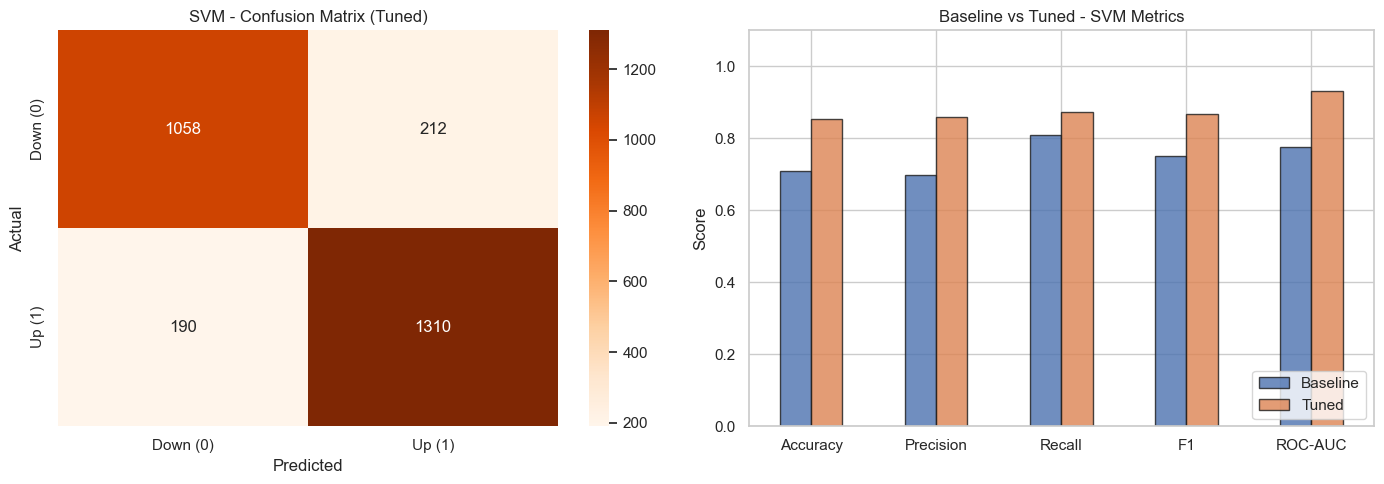


SVM Baseline vs Tuned Metrics:


,Baseline,Tuned
Accuracy,0.7079,0.8549
Precision,0.6987,0.8607
Recall,0.8100,0.8733
F1,0.7502,0.8670
ROC-AUC,0.7766,0.9316


In [10]:
# Plot SVM confusion matrix and compare baseline vs tuned metrics side by side
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix - tuned SVM
    cm_svc = confusion_matrix(y_test, y_pred_svc)
    sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    axes[0].set_title('SVM - Confusion Matrix (Tuned)')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Bar chart: SVM baseline vs tuned metrics
    svc_metrics_compare = pd.DataFrame({
        'Baseline': {
            'Accuracy' : accuracy_score(y_test, y_pred_svc_baseline),
            'Precision': precision_score(y_test, y_pred_svc_baseline),
            'Recall'   : recall_score(y_test, y_pred_svc_baseline),
            'F1'       : f1_score(y_test, y_pred_svc_baseline),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_svc_baseline)
        },
        'Tuned': {
            'Accuracy' : accuracy_score(y_test, y_pred_svc),
            'Precision': precision_score(y_test, y_pred_svc),
            'Recall'   : recall_score(y_test, y_pred_svc),
            'F1'       : f1_score(y_test, y_pred_svc),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_svc)
        }
    })

    svc_metrics_compare.plot(kind='bar', ax=axes[1], edgecolor='k', alpha=0.8)
    axes[1].set_title('Baseline vs Tuned - SVM Metrics')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'svm_evaluation.png'), bbox_inches='tight')
    plt.show()

    print("\nSVM Baseline vs Tuned Metrics:")
    display(svc_metrics_compare.round(4))

except Exception as e:
    print(f"[ERROR] SVM plotting failed: {e}")

In [11]:
from sklearn.tree import DecisionTreeClassifier

print("=" * 60)
print("=== STEP 3: DECISION TREE - BASELINE ===")
print("=" * 60)

# Train a baseline DecisionTreeClassifier with default parameters
try:
    dt_baseline = DecisionTreeClassifier(random_state=42)
    dt_baseline.fit(X_train, y_train)

    y_pred_dt_baseline = dt_baseline.predict(X_test)
    y_prob_dt_baseline = dt_baseline.predict_proba(X_test)[:, 1]

    print(f"Baseline Accuracy  : {accuracy_score(y_test, y_pred_dt_baseline):.4f}")
    print(f"Baseline Precision : {precision_score(y_test, y_pred_dt_baseline):.4f}")
    print(f"Baseline Recall    : {recall_score(y_test, y_pred_dt_baseline):.4f}")
    print(f"Baseline F1        : {f1_score(y_test, y_pred_dt_baseline):.4f}")
    print(f"Baseline ROC-AUC   : {roc_auc_score(y_test, y_prob_dt_baseline):.4f}")

except Exception as e:
    print(f"[ERROR] Baseline Decision Tree failed: {e}")

=== STEP 3: DECISION TREE - BASELINE ===
Baseline Accuracy  : 0.6462
Baseline Precision : 0.6667
Baseline Recall    : 0.6933
Baseline F1        : 0.6797
Baseline ROC-AUC   : 0.6419


In [12]:
print("=" * 60)
print("=== STEP 3: DECISION TREE - HYPERPARAMETER TUNING ===")
print("=" * 60)

# GridSearchCV over tree depth, split/leaf size, and split criterion; scored on roc_auc
dt_param_grid = {
    'max_depth'         : [3, 5, 7, 10, None],
    'min_samples_split' : [2, 5, 10, 20],
    'min_samples_leaf'  : [1, 2, 4, 8],
    'criterion'         : ['gini', 'entropy']
}

try:
    dt_grid = GridSearchCV(
        estimator  = DecisionTreeClassifier(random_state=42),
        param_grid = dt_param_grid,
        scoring    = 'roc_auc',
        refit      = True,
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    dt_grid.fit(X_train, y_train)

    print(f"\nBest hyperparameters found:")
    for param, val in dt_grid.best_params_.items():
        print(f"  {param}: {val}")
    print(f"\nBest CV ROC-AUC: {dt_grid.best_score_:.4f}")

except Exception as e:
    print(f"[ERROR] GridSearchCV for Decision Tree failed: {e}")

=== STEP 3: DECISION TREE - HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best hyperparameters found:
  criterion: entropy
  max_depth: 7
  min_samples_leaf: 8
  min_samples_split: 20

Best CV ROC-AUC: 0.7485


In [13]:
print("=" * 60)
print("=== STEP 3: DECISION TREE - FINAL PREDICTIONS ===")
print("=" * 60)

# Use the best estimator from GridSearchCV for final test set predictions
try:
    dt_best = dt_grid.best_estimator_

    y_pred_dt = dt_best.predict(X_test)
    y_prob_dt = dt_best.predict_proba(X_test)[:, 1]

    print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}")
    print(f"Tuned Precision : {precision_score(y_test, y_pred_dt):.4f}")
    print(f"Tuned Recall    : {recall_score(y_test, y_pred_dt):.4f}")
    print(f"Tuned F1        : {f1_score(y_test, y_pred_dt):.4f}")
    print(f"Tuned ROC-AUC   : {roc_auc_score(y_test, y_prob_dt):.4f}")

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred_dt, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    print(f"[ERROR] Final predictions for Decision Tree failed: {e}")

=== STEP 3: DECISION TREE - FINAL PREDICTIONS ===
Tuned Accuracy  : 0.6848
Tuned Precision : 0.7161
Tuned Recall    : 0.6927
Tuned F1        : 0.7042
Tuned ROC-AUC   : 0.7498

Classification Report:

              precision    recall  f1-score   support

    Down (0)       0.65      0.68      0.66      1270
      Up (1)       0.72      0.69      0.70      1500

    accuracy                           0.68      2770
   macro avg       0.68      0.68      0.68      2770
weighted avg       0.69      0.68      0.69      2770



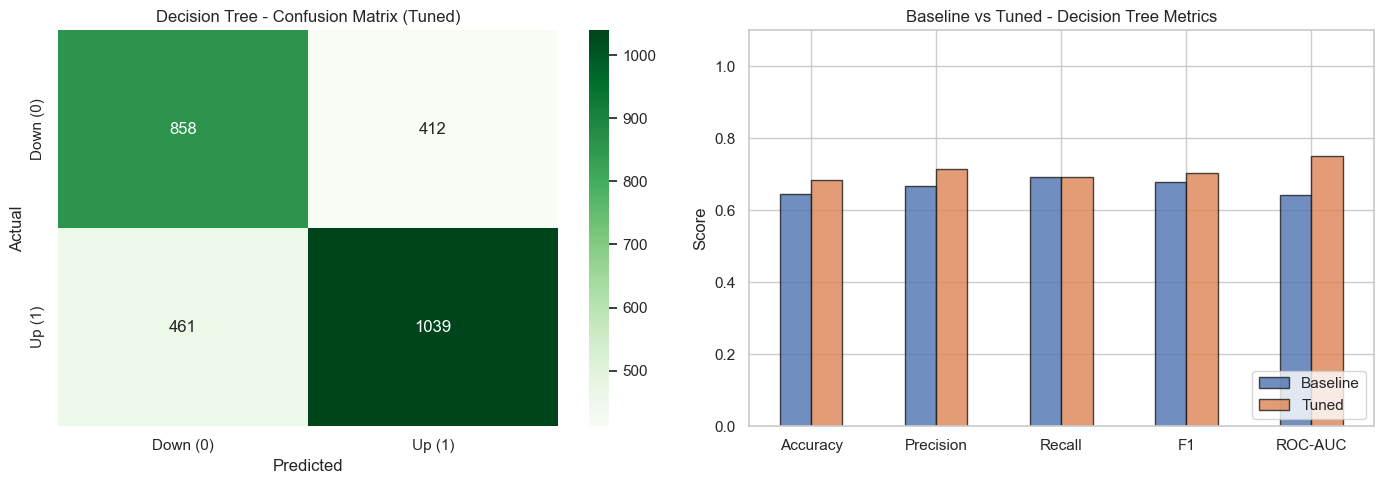


Decision Tree Baseline vs Tuned Metrics:


,Baseline,Tuned
Accuracy,0.6462,0.6848
Precision,0.6667,0.7161
Recall,0.6933,0.6927
F1,0.6797,0.7042
ROC-AUC,0.6419,0.7498


In [14]:
# Plot Decision Tree confusion matrix and compare baseline vs tuned metrics
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix - tuned Decision Tree
    cm_dt = confusion_matrix(y_test, y_pred_dt)
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0],
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    axes[0].set_title('Decision Tree - Confusion Matrix (Tuned)')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Bar chart: Decision Tree baseline vs tuned metrics
    dt_metrics_compare = pd.DataFrame({
        'Baseline': {
            'Accuracy' : accuracy_score(y_test, y_pred_dt_baseline),
            'Precision': precision_score(y_test, y_pred_dt_baseline),
            'Recall'   : recall_score(y_test, y_pred_dt_baseline),
            'F1'       : f1_score(y_test, y_pred_dt_baseline),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_dt_baseline)
        },
        'Tuned': {
            'Accuracy' : accuracy_score(y_test, y_pred_dt),
            'Precision': precision_score(y_test, y_pred_dt),
            'Recall'   : recall_score(y_test, y_pred_dt),
            'F1'       : f1_score(y_test, y_pred_dt),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_dt)
        }
    })

    dt_metrics_compare.plot(kind='bar', ax=axes[1], edgecolor='k', alpha=0.8)
    axes[1].set_title('Baseline vs Tuned - Decision Tree Metrics')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'dt_evaluation.png'), bbox_inches='tight')
    plt.show()

    print("\nDecision Tree Baseline vs Tuned Metrics:")
    display(dt_metrics_compare.round(4))

except Exception as e:
    print(f"[ERROR] Decision Tree plotting failed: {e}")

In [15]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("=== STEP 4: RANDOM FOREST - BASELINE ===")
print("=" * 60)

# Train a baseline RandomForestClassifier with default parameters
try:
    rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_baseline.fit(X_train, y_train)

    y_pred_rf_baseline = rf_baseline.predict(X_test)
    y_prob_rf_baseline = rf_baseline.predict_proba(X_test)[:, 1]

    print(f"Baseline Accuracy  : {accuracy_score(y_test, y_pred_rf_baseline):.4f}")
    print(f"Baseline Precision : {precision_score(y_test, y_pred_rf_baseline):.4f}")
    print(f"Baseline Recall    : {recall_score(y_test, y_pred_rf_baseline):.4f}")
    print(f"Baseline F1        : {f1_score(y_test, y_pred_rf_baseline):.4f}")
    print(f"Baseline ROC-AUC   : {roc_auc_score(y_test, y_prob_rf_baseline):.4f}")

except Exception as e:
    print(f"[ERROR] Baseline Random Forest failed: {e}")

=== STEP 4: RANDOM FOREST - BASELINE ===
Baseline Accuracy  : 0.7144
Baseline Precision : 0.7187
Baseline Recall    : 0.7767
Baseline F1        : 0.7466
Baseline ROC-AUC   : 0.7880


In [16]:
from sklearn.model_selection import RandomizedSearchCV

print("=" * 60)
print("=== STEP 4: RANDOM FOREST - HYPERPARAMETER TUNING ===")
print("=" * 60)

# RandomizedSearchCV (faster than GridSearch for large param spaces); scored on roc_auc
rf_param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [5, 10, 15, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2']
}

try:
    rf_search = RandomizedSearchCV(
        estimator          = RandomForestClassifier(random_state=42, n_jobs=-1),
        param_distributions = rf_param_dist,
        n_iter             = 30,
        scoring            = 'roc_auc',
        refit              = True,
        cv                 = 5,
        n_jobs             = -1,
        random_state       = 42,
        verbose            = 1
    )
    rf_search.fit(X_train, y_train)

    print(f"\nBest hyperparameters found:")
    for param, val in rf_search.best_params_.items():
        print(f"  {param}: {val}")
    print(f"\nBest CV ROC-AUC: {rf_search.best_score_:.4f}")

except Exception as e:
    print(f"[ERROR] RandomizedSearchCV for Random Forest failed: {e}")

=== STEP 4: RANDOM FOREST - HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters found:
  n_estimators: 300
  min_samples_split: 10
  min_samples_leaf: 4
  max_features: log2
  max_depth: None

Best CV ROC-AUC: 0.7912


In [17]:
print("=" * 60)
print("=== STEP 4: RANDOM FOREST - FINAL PREDICTIONS ===")
print("=" * 60)

# Use the best estimator from RandomizedSearchCV for final test set predictions
try:
    rf_best = rf_search.best_estimator_

    y_pred_rf = rf_best.predict(X_test)
    y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

    print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
    print(f"Tuned Precision : {precision_score(y_test, y_pred_rf):.4f}")
    print(f"Tuned Recall    : {recall_score(y_test, y_pred_rf):.4f}")
    print(f"Tuned F1        : {f1_score(y_test, y_pred_rf):.4f}")
    print(f"Tuned ROC-AUC   : {roc_auc_score(y_test, y_prob_rf):.4f}")

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred_rf, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    print(f"[ERROR] Final predictions for Random Forest failed: {e}")

=== STEP 4: RANDOM FOREST - FINAL PREDICTIONS ===
Tuned Accuracy  : 0.7184
Tuned Precision : 0.7190
Tuned Recall    : 0.7880
Tuned F1        : 0.7519
Tuned ROC-AUC   : 0.7950

Classification Report:

              precision    recall  f1-score   support

    Down (0)       0.72      0.64      0.67      1270
      Up (1)       0.72      0.79      0.75      1500

    accuracy                           0.72      2770
   macro avg       0.72      0.71      0.71      2770
weighted avg       0.72      0.72      0.72      2770



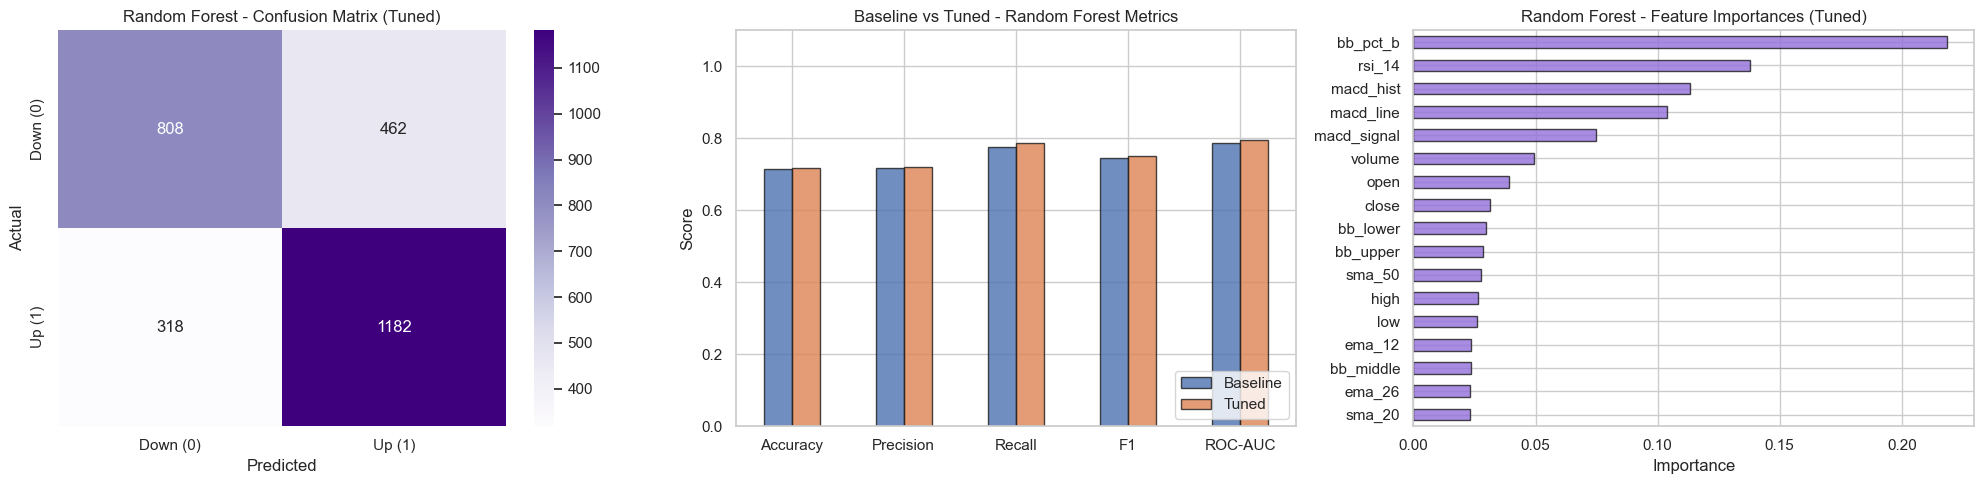


Random Forest Baseline vs Tuned Metrics:


,Baseline,Tuned
Accuracy,0.7144,0.7184
Precision,0.7187,0.7190
Recall,0.7767,0.7880
F1,0.7466,0.7519
ROC-AUC,0.7880,0.7950


In [18]:
# Plot Random Forest confusion matrix, baseline vs tuned metrics, and feature importances
try:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Confusion matrix - tuned Random Forest
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=axes[0],
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    axes[0].set_title('Random Forest - Confusion Matrix (Tuned)')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Bar chart: Random Forest baseline vs tuned metrics
    rf_metrics_compare = pd.DataFrame({
        'Baseline': {
            'Accuracy' : accuracy_score(y_test, y_pred_rf_baseline),
            'Precision': precision_score(y_test, y_pred_rf_baseline),
            'Recall'   : recall_score(y_test, y_pred_rf_baseline),
            'F1'       : f1_score(y_test, y_pred_rf_baseline),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_rf_baseline)
        },
        'Tuned': {
            'Accuracy' : accuracy_score(y_test, y_pred_rf),
            'Precision': precision_score(y_test, y_pred_rf),
            'Recall'   : recall_score(y_test, y_pred_rf),
            'F1'       : f1_score(y_test, y_pred_rf),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_rf)
        }
    })

    rf_metrics_compare.plot(kind='bar', ax=axes[1], edgecolor='k', alpha=0.8)
    axes[1].set_title('Baseline vs Tuned - Random Forest Metrics')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='lower right')

    # Feature importances from tuned Random Forest
    feature_importances = pd.Series(rf_best.feature_importances_, index=X_train.columns)
    feature_importances.sort_values().plot(kind='barh', ax=axes[2], color='mediumpurple', edgecolor='k', alpha=0.8)
    axes[2].set_title('Random Forest - Feature Importances (Tuned)')
    axes[2].set_xlabel('Importance')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'rf_evaluation.png'), bbox_inches='tight')
    plt.show()

    print("\nRandom Forest Baseline vs Tuned Metrics:")
    display(rf_metrics_compare.round(4))

except Exception as e:
    print(f"[ERROR] Random Forest plotting failed: {e}")

In [19]:
from sklearn.ensemble import AdaBoostClassifier

print("=" * 60)
print("=== STEP 5: ADABOOST - BASELINE ===")
print("=" * 60)

# Train a baseline AdaBoostClassifier with default parameters
try:
    ada_baseline = AdaBoostClassifier(random_state=42)
    ada_baseline.fit(X_train, y_train)

    y_pred_ada_baseline = ada_baseline.predict(X_test)
    y_prob_ada_baseline = ada_baseline.predict_proba(X_test)[:, 1]

    print(f"Baseline Accuracy  : {accuracy_score(y_test, y_pred_ada_baseline):.4f}")
    print(f"Baseline Precision : {precision_score(y_test, y_pred_ada_baseline):.4f}")
    print(f"Baseline Recall    : {recall_score(y_test, y_pred_ada_baseline):.4f}")
    print(f"Baseline F1        : {f1_score(y_test, y_pred_ada_baseline):.4f}")
    print(f"Baseline ROC-AUC   : {roc_auc_score(y_test, y_prob_ada_baseline):.4f}")

except Exception as e:
    print(f"[ERROR] Baseline AdaBoost failed: {e}")

=== STEP 5: ADABOOST - BASELINE ===
Baseline Accuracy  : 0.6646
Baseline Precision : 0.6571
Baseline Recall    : 0.7960
Baseline F1        : 0.7199
Baseline ROC-AUC   : 0.7545


In [20]:
print("=" * 60)
print("=== STEP 5: ADABOOST - HYPERPARAMETER TUNING ===")
print("=" * 60)

# GridSearchCV over n_estimators and learning_rate
# Note: 'algorithm' parameter removed in scikit-learn 1.6+ (SAMME is now the only algorithm)
ada_param_grid = {
    'n_estimators'  : [50, 100, 200, 300],
    'learning_rate' : [0.01, 0.1, 0.5, 1.0]
}

ada_scoring = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1',
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall'
}

try:
    ada_grid = GridSearchCV(
        estimator  = AdaBoostClassifier(random_state=42),
        param_grid = ada_param_grid,
        scoring    = ada_scoring,
        refit      = 'roc_auc',
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    ada_grid.fit(X_train, y_train)

    print(f"Best hyperparameters found:")
    for param, val in ada_grid.best_params_.items():
        print(f"  {param}: {val}")
    print(f"Best CV ROC-AUC: {ada_grid.best_score_:.4f}")

except Exception as e:
    print(f"[ERROR] GridSearchCV for AdaBoost failed: {e}")

=== STEP 5: ADABOOST - HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best hyperparameters found:
  learning_rate: 1.0
  n_estimators: 300
Best CV ROC-AUC: 0.7806


In [21]:
print("=" * 60)
print("=== STEP 5: ADABOOST - FINAL PREDICTIONS ===")
print("=" * 60)

# Use the best estimator from GridSearchCV for final test set predictions
try:
    ada_best = ada_grid.best_estimator_

    y_pred_ada = ada_best.predict(X_test)
    y_prob_ada = ada_best.predict_proba(X_test)[:, 1]

    print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_ada):.4f}")
    print(f"Tuned Precision : {precision_score(y_test, y_pred_ada):.4f}")
    print(f"Tuned Recall    : {recall_score(y_test, y_pred_ada):.4f}")
    print(f"Tuned F1        : {f1_score(y_test, y_pred_ada):.4f}")
    print(f"Tuned ROC-AUC   : {roc_auc_score(y_test, y_prob_ada):.4f}")

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred_ada, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    print(f"[ERROR] Final predictions for AdaBoost failed: {e}")

=== STEP 5: ADABOOST - FINAL PREDICTIONS ===
Tuned Accuracy  : 0.7025
Tuned Precision : 0.7036
Tuned Recall    : 0.7787
Tuned F1        : 0.7392
Tuned ROC-AUC   : 0.7736

Classification Report:

              precision    recall  f1-score   support

    Down (0)       0.70      0.61      0.65      1270
      Up (1)       0.70      0.78      0.74      1500

    accuracy                           0.70      2770
   macro avg       0.70      0.70      0.70      2770
weighted avg       0.70      0.70      0.70      2770



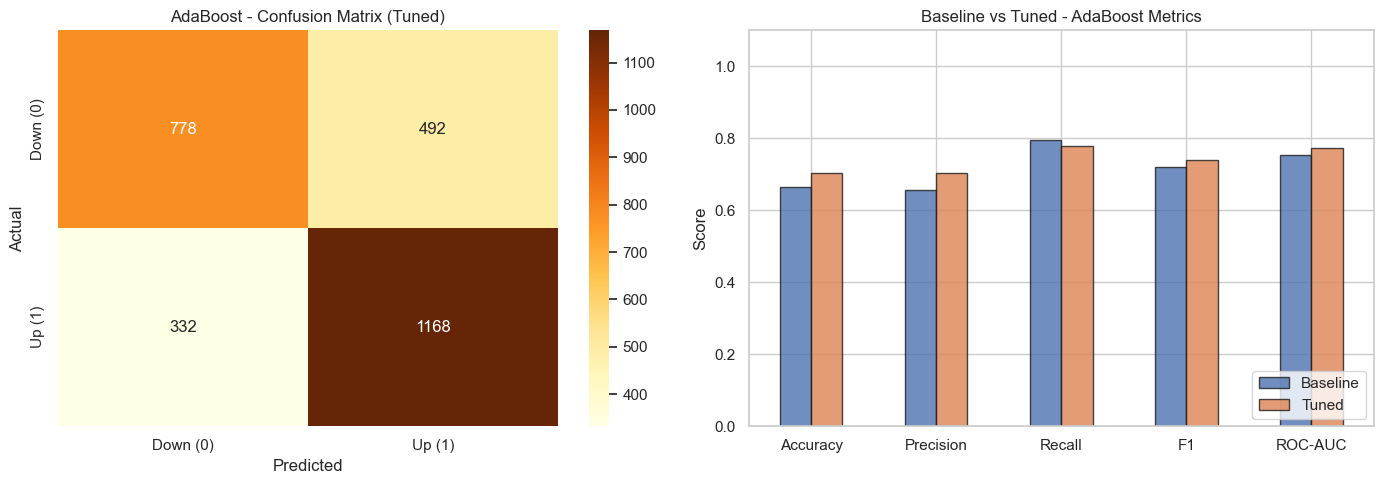


AdaBoost Baseline vs Tuned Metrics:


,Baseline,Tuned
Accuracy,0.6646,0.7025
Precision,0.6571,0.7036
Recall,0.7960,0.7787
F1,0.7199,0.7392
ROC-AUC,0.7545,0.7736


In [22]:
# Plot AdaBoost confusion matrix and compare baseline vs tuned metrics
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix - tuned AdaBoost
    cm_ada = confusion_matrix(y_test, y_pred_ada)
    sns.heatmap(cm_ada, annot=True, fmt='d', cmap='YlOrBr', ax=axes[0],
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    axes[0].set_title('AdaBoost - Confusion Matrix (Tuned)')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Bar chart: AdaBoost baseline vs tuned metrics
    ada_metrics_compare = pd.DataFrame({
        'Baseline': {
            'Accuracy' : accuracy_score(y_test, y_pred_ada_baseline),
            'Precision': precision_score(y_test, y_pred_ada_baseline),
            'Recall'   : recall_score(y_test, y_pred_ada_baseline),
            'F1'       : f1_score(y_test, y_pred_ada_baseline),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_ada_baseline)
        },
        'Tuned': {
            'Accuracy' : accuracy_score(y_test, y_pred_ada),
            'Precision': precision_score(y_test, y_pred_ada),
            'Recall'   : recall_score(y_test, y_pred_ada),
            'F1'       : f1_score(y_test, y_pred_ada),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_ada)
        }
    })

    ada_metrics_compare.plot(kind='bar', ax=axes[1], edgecolor='k', alpha=0.8)
    axes[1].set_title('Baseline vs Tuned - AdaBoost Metrics')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'ada_evaluation.png'), bbox_inches='tight')
    plt.show()

    print("\nAdaBoost Baseline vs Tuned Metrics:")
    display(ada_metrics_compare.round(4))

except Exception as e:
    print(f"[ERROR] AdaBoost plotting failed: {e}")

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

print("=" * 60)
print("=== STEP 6: GRADIENT BOOSTING (GBM) - BASELINE ===")
print("=" * 60)

# Train a baseline GradientBoostingClassifier with default parameters
try:
    gbm_baseline = GradientBoostingClassifier(random_state=42)
    gbm_baseline.fit(X_train, y_train)

    y_pred_gbm_baseline = gbm_baseline.predict(X_test)
    y_prob_gbm_baseline = gbm_baseline.predict_proba(X_test)[:, 1]

    print(f"Baseline Accuracy  : {accuracy_score(y_test, y_pred_gbm_baseline):.4f}")
    print(f"Baseline Precision : {precision_score(y_test, y_pred_gbm_baseline):.4f}")
    print(f"Baseline Recall    : {recall_score(y_test, y_pred_gbm_baseline):.4f}")
    print(f"Baseline F1        : {f1_score(y_test, y_pred_gbm_baseline):.4f}")
    print(f"Baseline ROC-AUC   : {roc_auc_score(y_test, y_prob_gbm_baseline):.4f}")

except Exception as e:
    print(f"[ERROR] Baseline GBM failed: {e}")

=== STEP 6: GRADIENT BOOSTING (GBM) - BASELINE ===
Baseline Accuracy  : 0.7130
Baseline Precision : 0.7140
Baseline Recall    : 0.7840
Baseline F1        : 0.7474
Baseline ROC-AUC   : 0.7928


In [24]:
print("=" * 60)
print("=== STEP 6: GRADIENT BOOSTING (GBM) - HYPERPARAMETER TUNING ===")
print("=" * 60)

# RandomizedSearchCV over learning rate, depth, splits, and subsample; scored on roc_auc
gbm_param_dist = {
    'n_estimators'      : [100, 200, 300],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2],
    'max_depth'         : [3, 5, 7],
    'min_samples_split' : [2, 5, 10],
    'subsample'         : [0.7, 0.8, 1.0]
}

try:
    gbm_search = RandomizedSearchCV(
        estimator           = GradientBoostingClassifier(random_state=42),
        param_distributions = gbm_param_dist,
        n_iter              = 30,
        scoring             = 'roc_auc',
        refit               = True,
        cv                  = 5,
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 1
    )
    gbm_search.fit(X_train, y_train)

    print(f"\nBest hyperparameters found:")
    for param, val in gbm_search.best_params_.items():
        print(f"  {param}: {val}")
    print(f"\nBest CV ROC-AUC: {gbm_search.best_score_:.4f}")

except Exception as e:
    print(f"[ERROR] RandomizedSearchCV for GBM failed: {e}")

=== STEP 6: GRADIENT BOOSTING (GBM) - HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters found:
  subsample: 0.8
  n_estimators: 300
  min_samples_split: 5
  max_depth: 7
  learning_rate: 0.2

Best CV ROC-AUC: 0.8144


In [25]:
print("=" * 60)
print("=== STEP 6: GRADIENT BOOSTING (GBM) - FINAL PREDICTIONS ===")
print("=" * 60)

# Use the best estimator from RandomizedSearchCV for final test set predictions
try:
    gbm_best = gbm_search.best_estimator_

    y_pred_gbm = gbm_best.predict(X_test)
    y_prob_gbm = gbm_best.predict_proba(X_test)[:, 1]

    print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_gbm):.4f}")
    print(f"Tuned Precision : {precision_score(y_test, y_pred_gbm):.4f}")
    print(f"Tuned Recall    : {recall_score(y_test, y_pred_gbm):.4f}")
    print(f"Tuned F1        : {f1_score(y_test, y_pred_gbm):.4f}")
    print(f"Tuned ROC-AUC   : {roc_auc_score(y_test, y_prob_gbm):.4f}")

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred_gbm, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    print(f"[ERROR] Final predictions for GBM failed: {e}")

=== STEP 6: GRADIENT BOOSTING (GBM) - FINAL PREDICTIONS ===
Tuned Accuracy  : 0.7455
Tuned Precision : 0.7387
Tuned Recall    : 0.8200
Tuned F1        : 0.7773
Tuned ROC-AUC   : 0.8215

Classification Report:

              precision    recall  f1-score   support

    Down (0)       0.76      0.66      0.70      1270
      Up (1)       0.74      0.82      0.78      1500

    accuracy                           0.75      2770
   macro avg       0.75      0.74      0.74      2770
weighted avg       0.75      0.75      0.74      2770



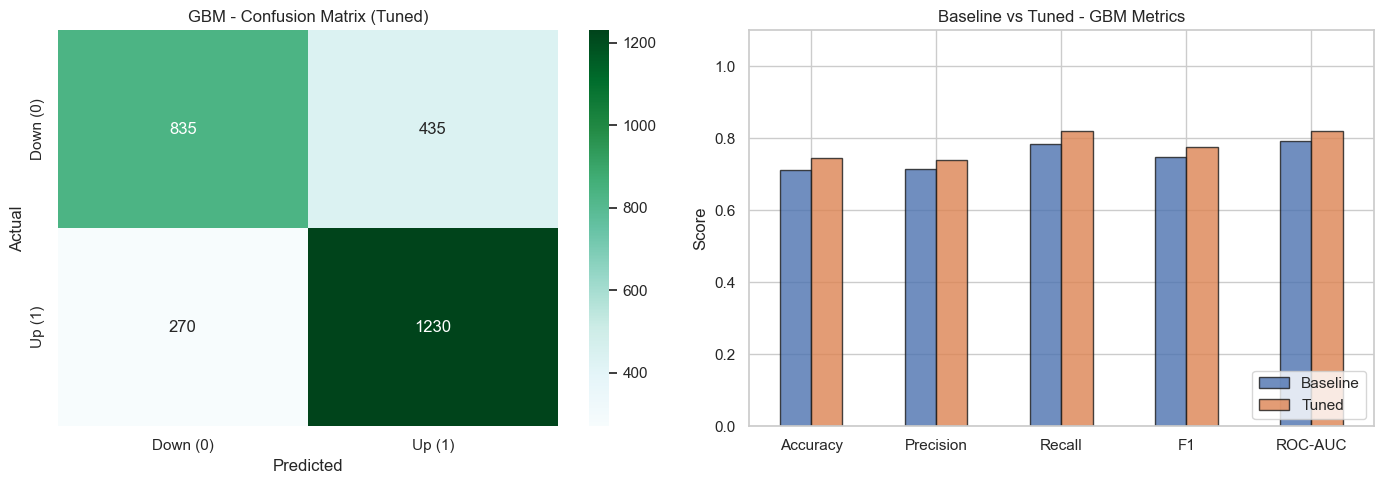


GBM Baseline vs Tuned Metrics:


,Baseline,Tuned
Accuracy,0.7130,0.7455
Precision,0.7140,0.7387
Recall,0.7840,0.8200
F1,0.7474,0.7773
ROC-AUC,0.7928,0.8215


In [26]:
# Plot GBM confusion matrix and compare baseline vs tuned metrics
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix - tuned GBM
    cm_gbm = confusion_matrix(y_test, y_pred_gbm)
    sns.heatmap(cm_gbm, annot=True, fmt='d', cmap='BuGn', ax=axes[0],
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    axes[0].set_title('GBM - Confusion Matrix (Tuned)')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Bar chart: GBM baseline vs tuned metrics
    gbm_metrics_compare = pd.DataFrame({
        'Baseline': {
            'Accuracy' : accuracy_score(y_test, y_pred_gbm_baseline),
            'Precision': precision_score(y_test, y_pred_gbm_baseline),
            'Recall'   : recall_score(y_test, y_pred_gbm_baseline),
            'F1'       : f1_score(y_test, y_pred_gbm_baseline),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_gbm_baseline)
        },
        'Tuned': {
            'Accuracy' : accuracy_score(y_test, y_pred_gbm),
            'Precision': precision_score(y_test, y_pred_gbm),
            'Recall'   : recall_score(y_test, y_pred_gbm),
            'F1'       : f1_score(y_test, y_pred_gbm),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_gbm)
        }
    })

    gbm_metrics_compare.plot(kind='bar', ax=axes[1], edgecolor='k', alpha=0.8)
    axes[1].set_title('Baseline vs Tuned - GBM Metrics')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'gbm_evaluation.png'), bbox_inches='tight')
    plt.show()

    print("\nGBM Baseline vs Tuned Metrics:")
    display(gbm_metrics_compare.round(4))

except Exception as e:
    print(f"[ERROR] GBM plotting failed: {e}")

In [27]:
from xgboost import XGBClassifier

print("=" * 60)
print("=== STEP 7: XGBOOST - BASELINE ===")
print("=" * 60)

# Train a baseline XGBClassifier; eval_metric='logloss' suppresses default warnings
try:
    xgb_baseline = XGBClassifier(
        random_state = 42,
        n_jobs       = -1,
        eval_metric  = 'logloss',
        verbosity    = 0
    )
    xgb_baseline.fit(X_train, y_train)

    y_pred_xgb_baseline = xgb_baseline.predict(X_test)
    y_prob_xgb_baseline = xgb_baseline.predict_proba(X_test)[:, 1]

    print(f"Baseline Accuracy  : {accuracy_score(y_test, y_pred_xgb_baseline):.4f}")
    print(f"Baseline Precision : {precision_score(y_test, y_pred_xgb_baseline):.4f}")
    print(f"Baseline Recall    : {recall_score(y_test, y_pred_xgb_baseline):.4f}")
    print(f"Baseline F1        : {f1_score(y_test, y_pred_xgb_baseline):.4f}")
    print(f"Baseline ROC-AUC   : {roc_auc_score(y_test, y_prob_xgb_baseline):.4f}")

except Exception as e:
    print(f"[ERROR] Baseline XGBoost failed: {e}")

=== STEP 7: XGBOOST - BASELINE ===
Baseline Accuracy  : 0.7296
Baseline Precision : 0.7226
Baseline Recall    : 0.8127
Baseline F1        : 0.7650
Baseline ROC-AUC   : 0.8066


In [28]:
print("=" * 60)
print("=== STEP 7: XGBOOST - HYPERPARAMETER TUNING ===")
print("=" * 60)

# RandomizedSearchCV over trees, learning rate, depth, subsampling, and L1/L2 regularisation
xgb_param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'max_depth'       : [3, 5, 7, 9],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0]
}

try:
    xgb_search = RandomizedSearchCV(
        estimator           = XGBClassifier(
                                  random_state = 42,
                                  n_jobs       = -1,
                                  eval_metric  = 'logloss',
                                  verbosity    = 0
                              ),
        param_distributions = xgb_param_dist,
        n_iter              = 30,
        scoring             = 'roc_auc',
        refit               = True,
        cv                  = 5,
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 1
    )
    xgb_search.fit(X_train, y_train)

    print(f"\nBest hyperparameters found:")
    for param, val in xgb_search.best_params_.items():
        print(f"  {param}: {val}")
    print(f"\nBest CV ROC-AUC: {xgb_search.best_score_:.4f}")

except Exception as e:
    print(f"[ERROR] RandomizedSearchCV for XGBoost failed: {e}")

=== STEP 7: XGBOOST - HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters found:
  subsample: 0.8
  reg_lambda: 0.5
  reg_alpha: 0.5
  n_estimators: 500
  max_depth: 3
  learning_rate: 0.1
  colsample_bytree: 1.0

Best CV ROC-AUC: 0.8159


In [29]:
print("=" * 60)
print("=== STEP 7: XGBOOST - FINAL PREDICTIONS ===")
print("=" * 60)

# Use the best estimator from RandomizedSearchCV for final test set predictions
try:
    xgb_best = xgb_search.best_estimator_

    y_pred_xgb = xgb_best.predict(X_test)
    y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

    print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}")
    print(f"Tuned Precision : {precision_score(y_test, y_pred_xgb):.4f}")
    print(f"Tuned Recall    : {recall_score(y_test, y_pred_xgb):.4f}")
    print(f"Tuned F1        : {f1_score(y_test, y_pred_xgb):.4f}")
    print(f"Tuned ROC-AUC   : {roc_auc_score(y_test, y_prob_xgb):.4f}")

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred_xgb, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    print(f"[ERROR] Final predictions for XGBoost failed: {e}")

=== STEP 7: XGBOOST - FINAL PREDICTIONS ===
Tuned Accuracy  : 0.7339
Tuned Precision : 0.7286
Tuned Recall    : 0.8107
Tuned F1        : 0.7674
Tuned ROC-AUC   : 0.8133

Classification Report:

              precision    recall  f1-score   support

    Down (0)       0.74      0.64      0.69      1270
      Up (1)       0.73      0.81      0.77      1500

    accuracy                           0.73      2770
   macro avg       0.74      0.73      0.73      2770
weighted avg       0.73      0.73      0.73      2770



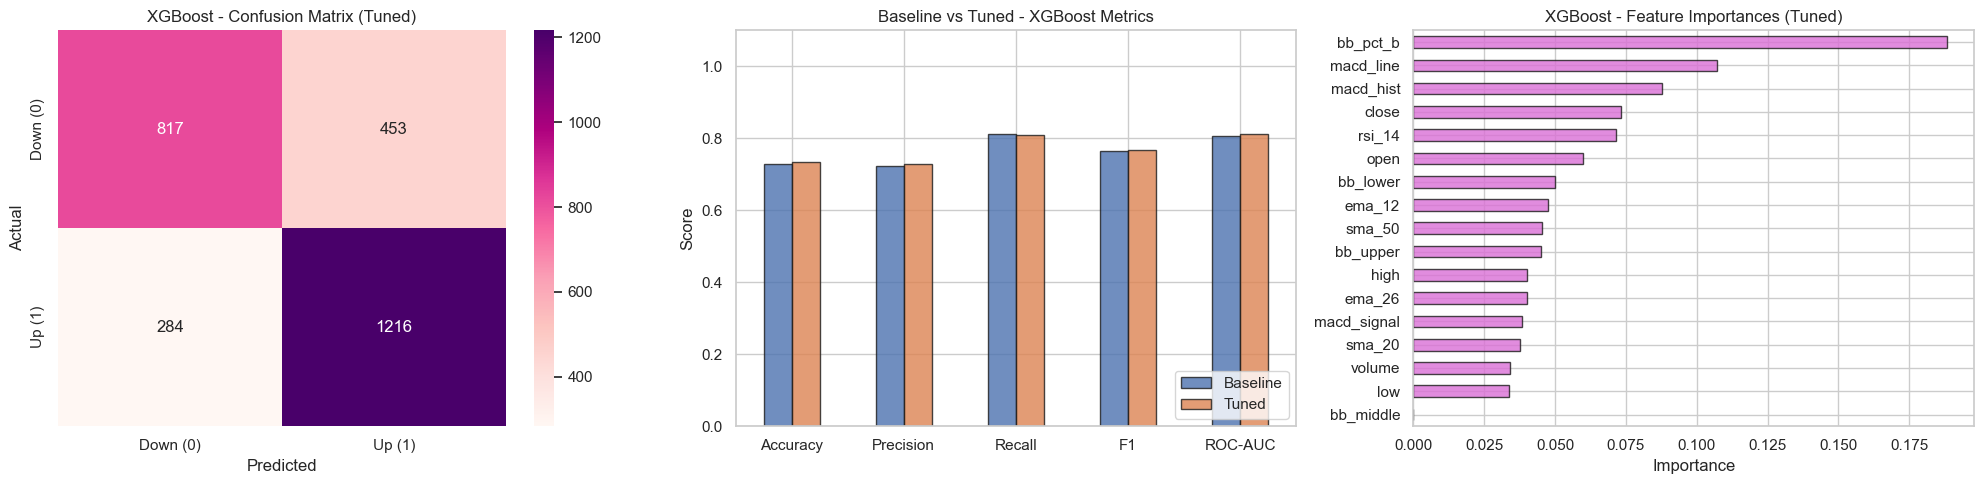


XGBoost Baseline vs Tuned Metrics:


,Baseline,Tuned
Accuracy,0.7296,0.7339
Precision,0.7226,0.7286
Recall,0.8127,0.8107
F1,0.7650,0.7674
ROC-AUC,0.8066,0.8133


In [30]:
# Plot XGBoost confusion matrix, baseline vs tuned metrics, and feature importances
try:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Confusion matrix - tuned XGBoost
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='RdPu', ax=axes[0],
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    axes[0].set_title('XGBoost - Confusion Matrix (Tuned)')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Bar chart: XGBoost baseline vs tuned metrics
    xgb_metrics_compare = pd.DataFrame({
        'Baseline': {
            'Accuracy' : accuracy_score(y_test, y_pred_xgb_baseline),
            'Precision': precision_score(y_test, y_pred_xgb_baseline),
            'Recall'   : recall_score(y_test, y_pred_xgb_baseline),
            'F1'       : f1_score(y_test, y_pred_xgb_baseline),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_xgb_baseline)
        },
        'Tuned': {
            'Accuracy' : accuracy_score(y_test, y_pred_xgb),
            'Precision': precision_score(y_test, y_pred_xgb),
            'Recall'   : recall_score(y_test, y_pred_xgb),
            'F1'       : f1_score(y_test, y_pred_xgb),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_xgb)
        }
    })

    xgb_metrics_compare.plot(kind='bar', ax=axes[1], edgecolor='k', alpha=0.8)
    axes[1].set_title('Baseline vs Tuned - XGBoost Metrics')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='lower right')

    # Feature importances from tuned XGBoost
    xgb_importances = pd.Series(xgb_best.feature_importances_, index=X_train.columns)
    xgb_importances.sort_values().plot(kind='barh', ax=axes[2], color='orchid', edgecolor='k', alpha=0.8)
    axes[2].set_title('XGBoost - Feature Importances (Tuned)')
    axes[2].set_xlabel('Importance')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'xgb_evaluation.png'), bbox_inches='tight')
    plt.show()

    print("\nXGBoost Baseline vs Tuned Metrics:")
    display(xgb_metrics_compare.round(4))

except Exception as e:
    print(f"[ERROR] XGBoost plotting failed: {e}")

In [31]:
import joblib

print("=" * 60)
print("=== SAVING ALL TRAINED MODELS TO DISK ===")
print("=" * 60)

# Save all baseline and tuned best models using joblib for use in 05_model_evaluation.ipynb
models_to_save = {
    # Baseline models
    "lr_baseline"  : lr_baseline,
    "svc_baseline" : svc_baseline,
    "dt_baseline"  : dt_baseline,
    "rf_baseline"  : rf_baseline,
    "ada_baseline" : ada_baseline,
    "gbm_baseline" : gbm_baseline,
    "xgb_baseline" : xgb_baseline,
    # Tuned best models
    "lr_best"      : lr_best,
    "svc_best"     : svc_best,
    "dt_best"      : dt_best,
    "rf_best"      : rf_best,
    "ada_best"     : ada_best,
    "gbm_best"     : gbm_best,
    "xgb_best"     : xgb_best,
}

try:
    for model_name, model_obj in models_to_save.items():
        save_path = os.path.join(output_dir, f"{model_name}.joblib")
        joblib.dump(model_obj, save_path)
        print(f"  Saved : {model_name}  →  {save_path}")
    print("[OK] All 14 models saved successfully.")
except Exception as e:
    print(f"[ERROR] Model saving failed: {e}")


=== SAVING ALL TRAINED MODELS TO DISK ===
  Saved : lr_baseline  →  ..\..\output\lr_baseline.joblib
  Saved : svc_baseline  →  ..\..\output\svc_baseline.joblib
  Saved : dt_baseline  →  ..\..\output\dt_baseline.joblib
  Saved : rf_baseline  →  ..\..\output\rf_baseline.joblib
  Saved : ada_baseline  →  ..\..\output\ada_baseline.joblib
  Saved : gbm_baseline  →  ..\..\output\gbm_baseline.joblib
  Saved : xgb_baseline  →  ..\..\output\xgb_baseline.joblib
  Saved : lr_best  →  ..\..\output\lr_best.joblib
  Saved : svc_best  →  ..\..\output\svc_best.joblib
  Saved : dt_best  →  ..\..\output\dt_best.joblib
  Saved : rf_best  →  ..\..\output\rf_best.joblib
  Saved : ada_best  →  ..\..\output\ada_best.joblib
  Saved : gbm_best  →  ..\..\output\gbm_best.joblib
  Saved : xgb_best  →  ..\..\output\xgb_best.joblib
[OK] All 14 models saved successfully.
